In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/sample_submission.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test_labels.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv
/kaggle/input/datasets/mrmorj/hate-speech-and-offensive-language-dataset/labeled_data.csv
/kaggle/input/datasets/sayankr007/cyber-bullying-data-for-multi-label-classification/Data_Distribution.png
/kaggle/input/datasets/sayankr007/cyber-bullying-data-for-multi-label-classification/final_hateXplain.csv
/kaggle/input/datasets/sayankr007/cyber-bullying-data-for-multi-label-classification/hateXplain.csv


In [3]:
import pandas as pd

# Hate Speech dataset
hate_df = pd.read_csv("/kaggle/input/datasets/mrmorj/hate-speech-and-offensive-language-dataset/labeled_data.csv")

# Jigsaw dataset
jigsaw_df = pd.read_csv("/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv")

# HateXplain dataset
hatexplain_df = pd.read_csv("/kaggle/input/datasets/sayankr007/cyber-bullying-data-for-multi-label-classification/hateXplain.csv")

In [4]:
print("Hate Speech dataset:")
print(hate_df.head())
print(hate_df.columns)



Hate Speech dataset:
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  
Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')


In [5]:
print("\nJigsaw dataset:")
print(jigsaw_df.head())
print(jigsaw_df.columns)

print("\nHateXplain dataset:")
print(hatexplain_df.head())
print(hatexplain_df.columns)


Jigsaw dataset:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  
Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

HateXplain data

In [6]:
print("Hate Speech info:")
print(hate_df.info())

print("\nJigsaw info:")
print(jigsaw_df.info())

print("\nHateXplain info:")
print(hatexplain_df.info())

Hate Speech info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None

Jigsaw info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 

In [7]:
# Hate Speech
hate_df_clean = hate_df[["tweet", "class"]].rename(columns={"tweet": "text"})

# Jigsaw
jigsaw_df_clean = jigsaw_df[["comment_text"]].copy()
jigsaw_df_clean["label"] = jigsaw_df[[
    "toxic", "severe_toxic", "obscene",
    "threat", "insult", "identity_hate"
]].max(axis=1)

jigsaw_df_clean = jigsaw_df_clean.rename(columns={"comment_text": "text"})

In [8]:
hate_df_clean["label"] = hate_df_clean["class"].apply(lambda x: 1 if x in [0,1] else 0)

In [9]:
hatexplain_df_clean = hatexplain_df[["post_tokens", "label"]].copy()

hatexplain_df_clean["text"] = hatexplain_df_clean["post_tokens"]

hatexplain_df_clean = hatexplain_df_clean[["text", "label"]]

In [10]:
hate_df_clean = hate_df[["tweet", "class"]].copy()
hate_df_clean = hate_df_clean.rename(columns={"tweet": "text"})

# convertir en binaire
hate_df_clean["label"] = hate_df_clean["class"].apply(lambda x: 1 if x in [0,1] else 0)

hate_df_clean = hate_df_clean[["text", "label"]]

In [11]:
jigsaw_df_clean = jigsaw_df[["comment_text"]].copy()

jigsaw_df_clean["label"] = jigsaw_df[[
    "toxic", "severe_toxic", "obscene",
    "threat", "insult", "identity_hate"
]].max(axis=1)

jigsaw_df_clean = jigsaw_df_clean.rename(columns={"comment_text": "text"})

In [12]:
hatexplain_df_clean = hatexplain_df[["post_tokens", "label"]].copy()

# pas de eval, déjà texte
hatexplain_df_clean = hatexplain_df_clean.rename(columns={"post_tokens": "text"})

In [13]:
final_df = pd.concat([
    hate_df_clean,
    jigsaw_df_clean,
    hatexplain_df_clean
], ignore_index=True)

print(final_df.shape)
final_df.head()

(244798, 2)


,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,0
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [14]:
print(final_df["label"].value_counts())
print(final_df.isnull().sum())

label
0             147509
1              36845
normal         24449
hatespeech     18070
offensive      17925
Name: count, dtype: int64
text     0
label    0
dtype: int64


In [16]:
import re

def clean_text(text):
    text = str(text)

    # remove RT @username:
    text = re.sub(r"RT\s+@\w+:", "", text)

    # remove @username
    text = re.sub(r"@\w+", "", text)

    # remove punctuation like !!! ??? ...
    text = re.sub(r"[!?.]+", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [17]:
final_df["text"] = final_df["text"].apply(clean_text)

In [18]:
def normalize_label(label):
    if label in [1, "hatespeech", "offensive"]:
        return 1
    else:
        return 0

final_df["label"] = final_df["label"].apply(normalize_label)

In [19]:
final_df["label"].value_counts()

label
0    171958
1     72840
Name: count, dtype: int64

In [20]:
final_df

,text,label
0,As a woman you shouldn't complain about cleani...,0
1,boy dats cold tyga dwn bad for cuffin dat hoe ...,1
2,RT Dawg You ever fuck a bitch and she start to...,1
3,she look like a tranny,1
4,The shit you hear about me might be true or it...,1
...,...,...
244793,it is awful look at world demographics asians ...,1
244794,it is awful look at world demographics asians ...,1
244795,the jewish globalist elite have only imported ...,1
244796,the jewish globalist elite have only imported ...,1


In [21]:
final_df = final_df.drop_duplicates()

print(final_df.shape)

(210336, 2)


In [22]:
final_df["length"] = final_df["text"].apply(len)

final_df = final_df[final_df["length"] > 5]

/tmp/ipykernel_57/2187108939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["length"] = final_df["text"].apply(len)


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=15000, stop_words="english")
X = vectorizer.fit_transform(final_df["text"])
y = final_df["label"]

In [23]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [25]:
final_df


,text,label,length
0,As a woman you shouldn't complain about cleani...,0,114
1,boy dats cold tyga dwn bad for cuffin dat hoe ...,1,62
2,RT Dawg You ever fuck a bitch and she start to...,1,74
3,she look like a tranny,1,22
4,The shit you hear about me might be true or it...,1,103
...,...,...,...
244788,when i first got on here and said i hate trump...,0,135
244789,was macht der moslem wenn der zion gegen seine...,1,129
244790,was macht der moslem wenn der zion gegen seine...,0,129
244792,it is awful look at world demographics asians ...,1,108


In [28]:
import pandas as pd
import re

# final_df doit contenir: text, label
final_df = final_df.dropna(subset=["text", "label"]).drop_duplicates().copy()
final_df["text"] = final_df["text"].astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"RT\s+@\w+:", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

final_df["text"] = final_df["text"].apply(clean_text)

def normalize_label(label):
    if label in [1, "hatespeech", "offensive"]:
        return 1
    return 0

final_df["label"] = final_df["label"].apply(normalize_label)

print(final_df.head())
print(final_df["label"].value_counts())

                                                text  label  length
0  as a woman you shouldn t complain about cleani...      0     114
1  boy dats cold tyga dwn bad for cuffin dat hoe ...      1      62
2  rt dawg you ever fuck a bitch and she start to...      1      74
3                             she look like a tranny      1      22
4  the shit you hear about me might be true or it...      1     103
label
0    158761
1     51555
Name: count, dtype: int64


# Transformer le texte en features

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=15000,
    stop_words="english",
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(final_df["text"])
y = final_df["label"]

# Split train/test

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train.shape, x_test.shape)

(168252, 15000) (42064, 15000)


# Entraîner un premier modèle NLP

**logistic regression**

In [29]:
from sklearn.linear_model import LogisticRegression

nlp_model = LogisticRegression(max_iter=1000, class_weight="balanced")
nlp_model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

# Évaluer

Accuracy: 0.9053109547356409
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     31753
           1       0.77      0.88      0.82     10311

    accuracy                           0.91     42064
   macro avg       0.86      0.90      0.88     42064
weighted avg       0.91      0.91      0.91     42064



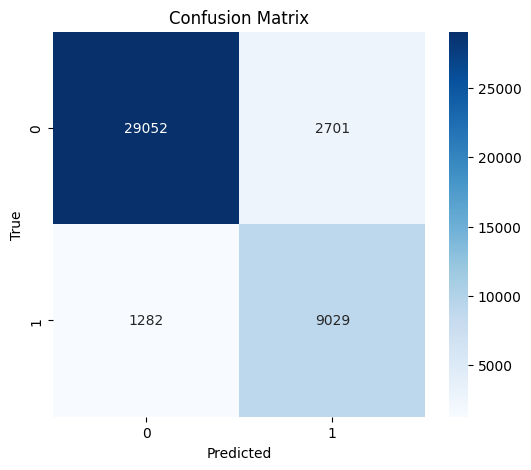

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = nlp_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

**linearsvc**

In [31]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight="balanced")
svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8982740585774058
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     31753
           1       0.76      0.87      0.81     10311

    accuracy                           0.90     42064
   macro avg       0.85      0.89      0.87     42064
weighted avg       0.91      0.90      0.90     42064



**XGBOOST**

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.895968048687714
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     31753
           1       0.90      0.64      0.75     10311

    accuracy                           0.90     42064
   macro avg       0.90      0.81      0.84     42064
weighted avg       0.90      0.90      0.89     42064



In [38]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(nlp_model, "best_nlp_model.pkl")

['best_nlp_model.pkl']

In [26]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib

# ── CHARGER les modèles ────────────────────────────────────────
vectorizer = joblib.load("tfidf_vectorizer.pkl")
nlp_model  = joblib.load("best_nlp_model.pkl")

In [31]:
# ── SHAP sur Logistic Regression ──────────────────────────────
explainer   = shap.LinearExplainer(nlp_model, x_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(x_test)

feature_names = vectorizer.get_feature_names_out()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


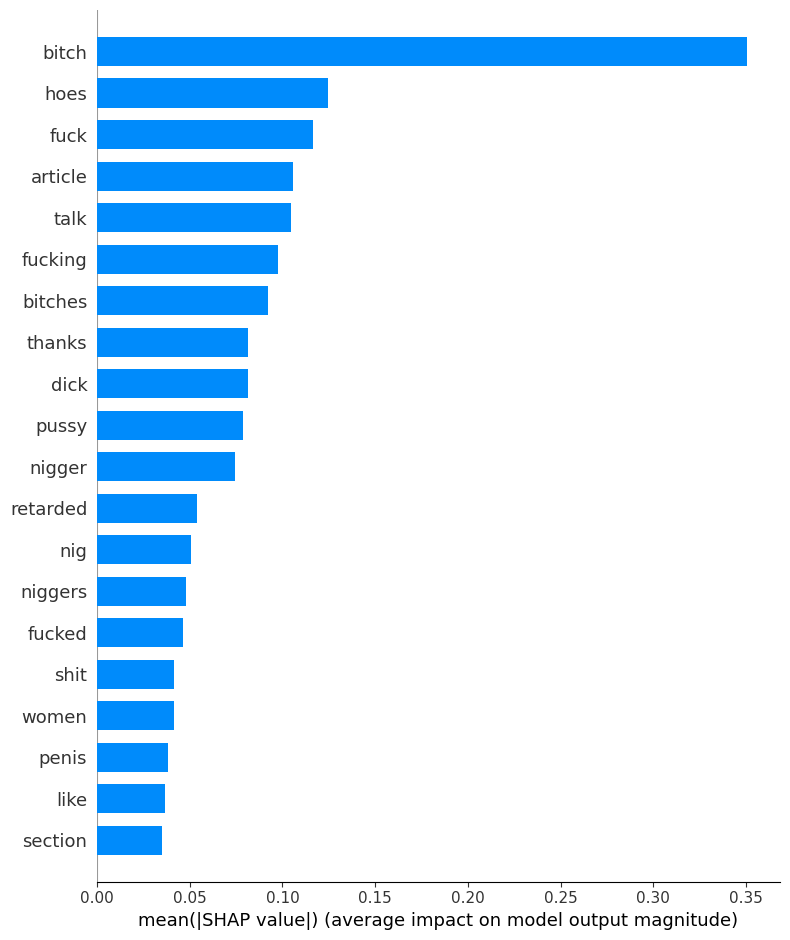

<Figure size 640x480 with 0 Axes>

In [32]:
# ── FIGURE 1 : Top 20 mots globaux les plus importants ────────
shap.summary_plot(
    shap_values, x_test,
    feature_names=feature_names,
    max_display=20,
    plot_type="bar",
    show=True
)
plt.savefig("shap_global.png", dpi=150, bbox_inches='tight')

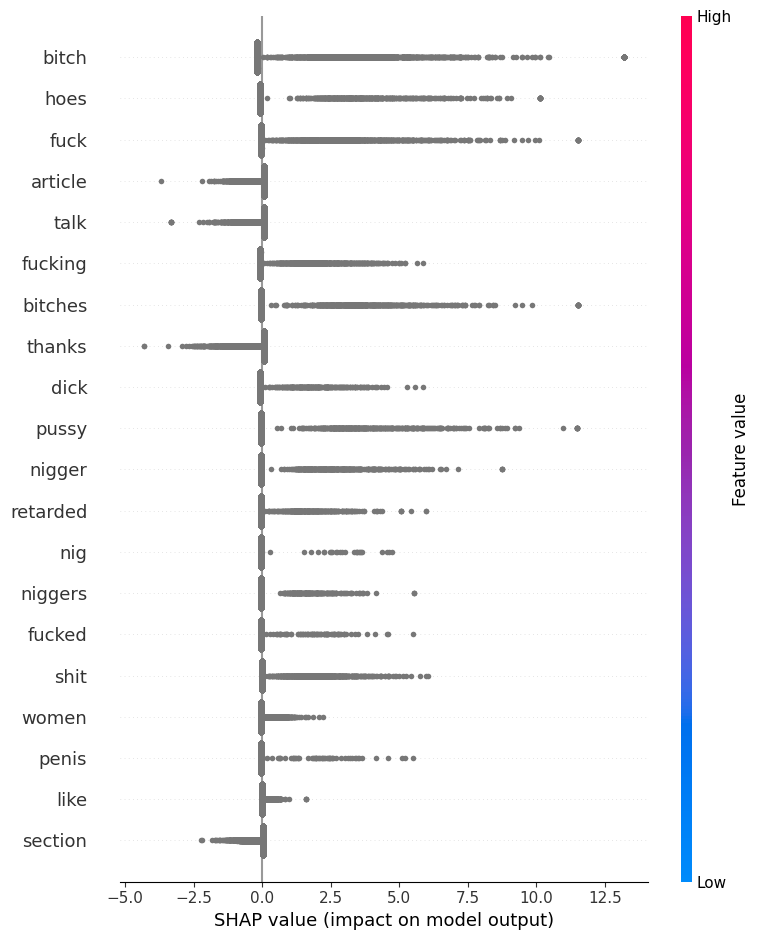

<Figure size 640x480 with 0 Axes>

In [33]:
# ── FIGURE 2 : Beeswarm — impact positif/négatif par mot ──────
shap.summary_plot(
    shap_values, x_test,
    feature_names=feature_names,
    max_display=20,
    show=True
)
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')

In [34]:
# ── FIGURE 3 : Expliquer UNE phrase précise ───────────────────
def explain_sentence(sentence, top_n=15):
    # Vectoriser la phrase
    vec = vectorizer.transform([sentence])
    
    # Prédiction
    pred       = nlp_model.predict(vec)[0]
    proba      = nlp_model.predict_proba(vec)[0]
    label      = "🔴 HATE/OFFENSIVE" if pred == 1 else "🟢 NORMAL"
    confidence = max(proba) * 100
    
    print(f"\nPhrase   : '{sentence}'")
    print(f"Décision : {label} ({confidence:.1f}%)")
    
    # SHAP pour cette phrase
    sv = explainer.shap_values(vec)
    
    # Top mots qui ont influencé
    feature_idx   = vec.nonzero()[1]
    word_shap     = [(feature_names[i], sv[0, i]) for i in feature_idx if sv[0, i] != 0]
    word_shap     = sorted(word_shap, key=lambda x: abs(x[1]), reverse=True)[:top_n]
    
    words  = [w for w, _ in word_shap]
    values = [v for _, v in word_shap]
    colors = ['red' if v > 0 else 'green' for v in values]
    
    plt.figure(figsize=(10, 5))
    bars = plt.barh(words[::-1], values[::-1], color=colors[::-1])
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.xlabel("SHAP value (rouge = pousse vers HATE, vert = pousse vers NORMAL)")
    plt.title(f"Mots déclencheurs — '{sentence[:50]}...'\n{label} ({confidence:.1f}%)")
    plt.tight_layout()
    plt.savefig("shap_sentence.png", dpi=150)
    plt.show()
    
    return pred, proba


Phrase   : 'I hate you so much you are disgusting'
Décision : 🔴 HATE/OFFENSIVE (95.0%)


/tmp/ipykernel_57/1499410744.py:32: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1499410744.py:33: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_sentence.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


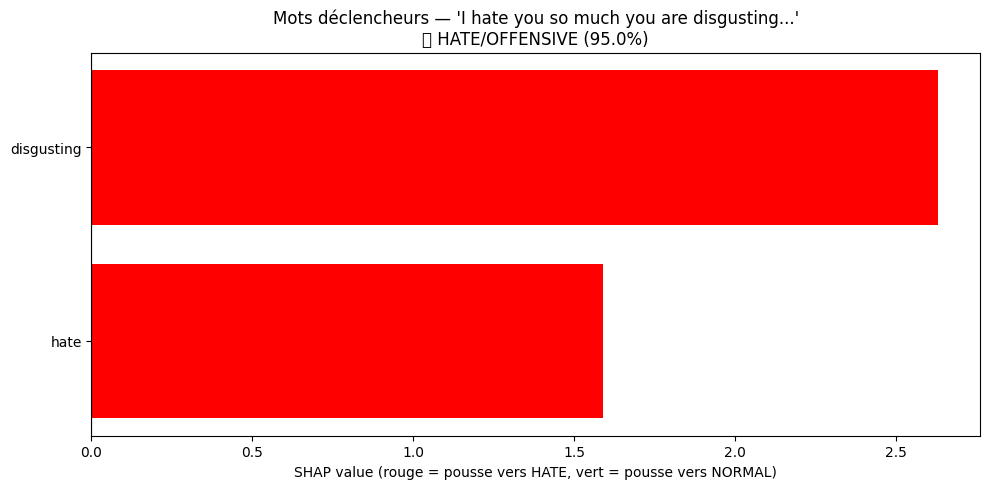

(np.int64(1), array([0.0496397, 0.9503603]))

In [35]:
# ── TESTER des phrases ─────────────────────────────────────────
explain_sentence("I hate you so much you are disgusting")


Phrase   : 'Have a great day everyone!'
Décision : 🟢 NORMAL (88.2%)


/tmp/ipykernel_57/1499410744.py:32: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1499410744.py:33: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_sentence.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


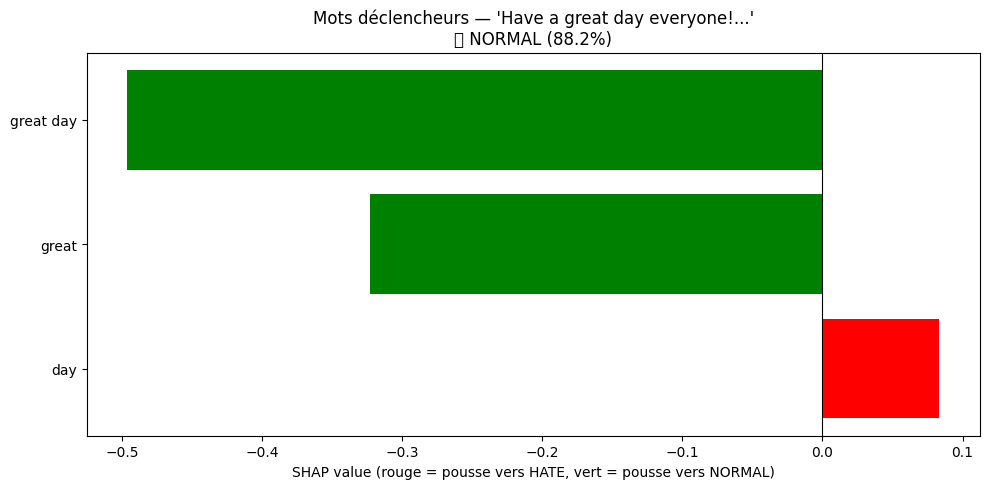

(np.int64(0), array([0.88205298, 0.11794702]))

In [36]:
explain_sentence("Have a great day everyone!")


Phrase   : 'Women are great leaders'
Décision : 🟢 NORMAL (52.2%)


/tmp/ipykernel_57/1499410744.py:32: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1499410744.py:33: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_sentence.png", dpi=150)


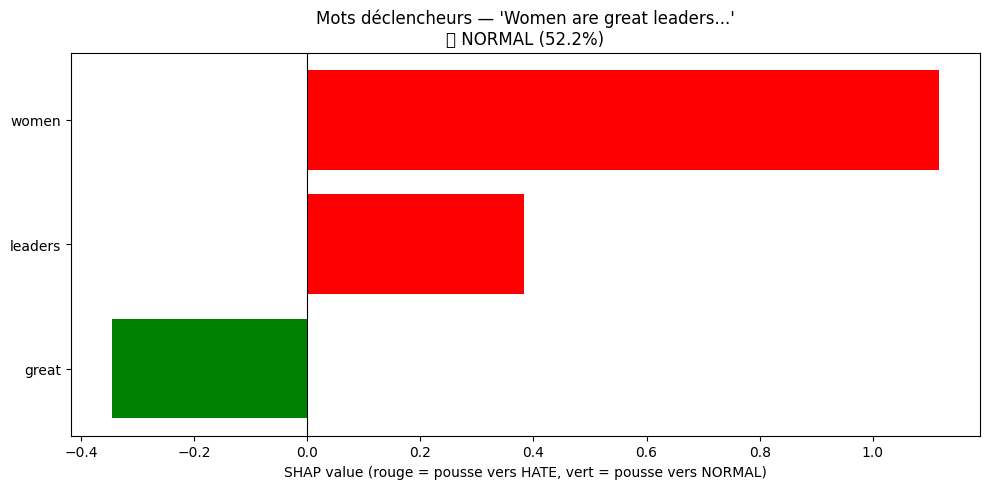


Phrase   : 'I love women'
Décision : 🔴 HATE/OFFENSIVE (52.6%)


/tmp/ipykernel_57/1499410744.py:32: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1499410744.py:33: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_sentence.png", dpi=150)


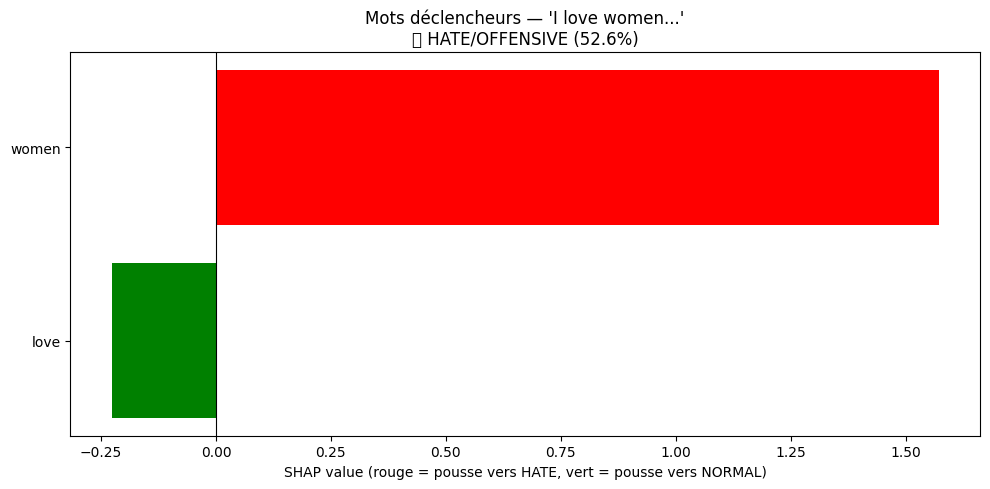

(np.int64(1), array([0.47419509, 0.52580491]))

In [38]:
# Teste cette phrase pour révéler le biais "women"
explain_sentence("Women are great leaders")
explain_sentence("I love women")

In [39]:
pip install transformers torch datasets

Note: you may need to restart the kernel to use updated packages.


In [40]:
import numpy as np
import pandas as pd
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ── VÉRIFIER GPU ───────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)  # doit afficher cuda sur Kaggle

Device: cuda


In [41]:
# ── PRÉPARER LES DONNÉES ───────────────────────────────────────
train_df, test_df = train_test_split(
    final_df[["text", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=final_df["label"]
)

# Convertir en Dataset HuggingFace
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

print("Train:", len(train_dataset), "| Test:", len(test_dataset))

Train: 168252 | Test: 42064


In [42]:
# ── TOKENIZER ─────────────────────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

# Renommer label pour HuggingFace
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/168252 [00:00<?, ? examples/s]

Map:   0%|          | 0/42064 [00:00<?, ? examples/s]

In [43]:
# ── MODÈLE ────────────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [44]:
# ── MÉTRIQUES ─────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [46]:
training_args = TrainingArguments(
    output_dir                  = "./distilbert_hate",
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",   # ← changé
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    logging_steps               = 50,
    fp16                        = True,
    report_to                   = "none"
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [47]:
# ── PRENDRE UN SUBSET ÉQUILIBRÉ ───────────────────────────────
df_hate   = final_df[final_df["label"] == 1].sample(8000, random_state=42)
df_normal = final_df[final_df["label"] == 0].sample(8000, random_state=42)
df_subset = pd.concat([df_hate, df_normal]).sample(frac=1, random_state=42)

print("Subset:", df_subset.shape)
print(df_subset["label"].value_counts())

train_df, test_df = train_test_split(
    df_subset[["text", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=df_subset["label"]
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Subset: (16000, 3)
label
0    8000
1    8000
Name: count, dtype: int64


Map:   0%|          | 0/12800 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

In [48]:
training_args = TrainingArguments(
    output_dir                  = "./distilbert_hate",
    num_train_epochs            = 2,        # ← 2 epochs suffisent
    per_device_train_batch_size = 64,
    per_device_eval_batch_size  = 128,
    learning_rate               = 3e-5,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    logging_steps               = 50,
    fp16                        = True,
    report_to                   = "none"
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.415821,0.417767,0.916875
2,0.363557,0.393558,0.920625


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=200, training_loss=0.3845651149749756, metrics={'train_runtime': 151.0842, 'train_samples_per_second': 169.442, 'train_steps_per_second': 1.324, 'total_flos': 847791351398400.0, 'train_loss': 0.3845651149749756, 'epoch': 2.0})

In [50]:
import torch
import numpy as np

def predict_bert(sentence):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding="max_length"
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

    probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred   = np.argmax(probs)
    label  = "🔴 HATE/OFFENSIVE" if pred == 1 else "🟢 NORMAL"
    print(f"{label} ({max(probs)*100:.1f}%)  →  '{sentence}'")

# ── TESTER ────────────────────────────────────────────────────
phrases = [
    "I love women",
    "Women are great leaders",
    "Women deserve equal rights",
    "I hate you so much",
    "Have a great day everyone!",
    "You people are always causing problems",
]

for phrase in phrases:
    predict_bert(phrase)

🔴 HATE/OFFENSIVE (60.7%)  →  'I love women'
🟢 NORMAL (68.5%)  →  'Women are great leaders'
🔴 HATE/OFFENSIVE (69.8%)  →  'Women deserve equal rights'
🔴 HATE/OFFENSIVE (62.6%)  →  'I hate you so much'
🟢 NORMAL (99.3%)  →  'Have a great day everyone!'
🟢 NORMAL (84.2%)  →  'You people are always causing problems'


In [51]:
# ── VOIR la distribution réelle du dataset ────────────────────
print(final_df["label"].value_counts())
print(final_df["label"].value_counts(normalize=True))

label
0    158761
1     51555
Name: count, dtype: int64
label
0    0.754869
1    0.245131
Name: proportion, dtype: float64


In [52]:
# ── DATASET ÉQUILIBRÉ 50/50 ───────────────────────────────────
df_hate   = final_df[final_df["label"] == 1].sample(10000, random_state=42)
df_normal = final_df[final_df["label"] == 0].sample(10000, random_state=42)

# Exemples correctifs
corrections = [
    ("I love women", 0),
    ("Women are great leaders", 0),
    ("Women deserve equal rights", 0),
    ("I respect all women", 0),
    ("Women in science are amazing", 0),
    ("I hate you so much", 1),
    ("I hate everyone", 1),
    ("You people are always causing problems", 1),
    ("Go back to your country", 1),
    ("You are disgusting and worthless", 1),
]
corrections_df = pd.DataFrame(corrections, columns=["text", "label"])
corrections_df = pd.concat([corrections_df] * 30, ignore_index=True)

df_balanced = pd.concat([df_hate, df_normal, corrections_df]).sample(frac=1, random_state=42)

print("✅ Distribution finale:")
print(df_balanced["label"].value_counts())
print(df_balanced["label"].value_counts(normalize=True))

✅ Distribution finale:
label
1    10150
0    10150
Name: count, dtype: int64
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [53]:
# ── RETOKENISER ───────────────────────────────────────────────
train_df2, test_df2 = train_test_split(
    df_balanced[["text", "label"]],
    test_size=0.2, random_state=42,
    stratify=df_balanced["label"]
)

train_ds2 = Dataset.from_pandas(train_df2.reset_index(drop=True))
test_ds2  = Dataset.from_pandas(test_df2.reset_index(drop=True))

train_ds2 = train_ds2.map(tokenize, batched=True)
test_ds2  = test_ds2.map(tokenize, batched=True)

train_ds2 = train_ds2.rename_column("label", "labels")
test_ds2  = test_ds2.rename_column("label", "labels")

train_ds2.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds2.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/16240 [00:00<?, ? examples/s]

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

In [54]:
# ── NOUVEAU MODÈLE ────────────────────────────────────────────
model2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

training_args2 = TrainingArguments(
    output_dir                  = "./distilbert_v2",
    num_train_epochs            = 3,
    per_device_train_batch_size = 64,
    per_device_eval_batch_size  = 128,
    learning_rate               = 2e-5,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    logging_steps               = 50,
    fp16                        = True,
    report_to                   = "none"
)

trainer2 = Trainer(
    model           = model2,
    args            = training_args2,
    train_dataset   = train_ds2,
    eval_dataset    = test_ds2,
    compute_metrics = compute_metrics
)

trainer2.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.724969,0.463271,0.907882
2,0.438085,0.407533,0.918473
3,0.355863,0.407657,0.919212


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=381, training_loss=0.5699105575641622, metrics={'train_runtime': 286.3386, 'train_samples_per_second': 170.148, 'train_steps_per_second': 1.331, 'total_flos': 1613452915630080.0, 'train_loss': 0.5699105575641622, 'epoch': 3.0})

In [55]:
# ── TEST FINAL ────────────────────────────────────────────────
def predict_bert2(sentence):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding="max_length"
    ).to(device)

    with torch.no_grad():
        logits = model2(**inputs).logits

    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred  = np.argmax(probs)
    label = "🔴 HATE/OFFENSIVE" if pred == 1 else "🟢 NORMAL"
    print(f"{label} ({max(probs)*100:.1f}%)  →  '{sentence}'")

for phrase in [
    "I love women",
    "Women are great leaders",
    "Women deserve equal rights",
    "I hate you so much",
    "Have a great day everyone!",
    "You people are always causing problems",
]:
    predict_bert2(phrase)

🟢 NORMAL (97.8%)  →  'I love women'
🟢 NORMAL (98.9%)  →  'Women are great leaders'
🟢 NORMAL (97.3%)  →  'Women deserve equal rights'
🔴 HATE/OFFENSIVE (95.2%)  →  'I hate you so much'
🟢 NORMAL (98.1%)  →  'Have a great day everyone!'
🔴 HATE/OFFENSIVE (93.0%)  →  'You people are always causing problems'


In [56]:
model2.save_pretrained("distilbert_hate_final_v2")
tokenizer.save_pretrained("distilbert_hate_final_v2")
print("✅ Modèle final sauvegardé !")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle final sauvegardé !


In [63]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

# ── CHARGER depuis le fichier sauvegardé ──────────────────────
model2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert_hate_final_v2",
    attn_implementation="eager"    # ← fix pour visualisation attention
).to(device)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert_hate_final_v2")

print("✅ Modèle chargé !")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Modèle chargé !


In [64]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention(sentence, true_label=None):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=False
    ).to(device)

    with torch.no_grad():
        outputs = model2(**inputs, output_attentions=True)

    # Prédiction
    probs      = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred       = np.argmax(probs)
    pred_label = "🔴 HATE" if pred == 1 else "🟢 NORMAL"
    confidence = max(probs) * 100

    # Tokens — enlever [PAD] et [CLS] [SEP]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    tokens = [t for t in tokens if t not in ["[PAD]", "[CLS]", "[SEP]"]]
    n = len(tokens)

    # Attention dernière couche — moyenne des têtes
    attention = outputs.attentions[-1][0]        # (heads, seq, seq)
    attention = attention.mean(dim=0)            # (seq, seq)
    attention = attention.cpu().numpy()
    attention = attention[1:n+1, 1:n+1]         # enlever [CLS] [SEP]

    # Score importance par token
    importance = attention.mean(axis=0)
    importance = (importance - importance.min()) / (importance.max() - importance.min() + 1e-8)

    # ── FIGURE ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, n * 0.4)))

    # Graphe 1 : barres importance
    colors = ['red' if imp > 0.5 else 'steelblue' for imp in importance]
    axes[0].barh(tokens[::-1], importance[::-1], color=colors[::-1])
    axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_title(f"Importance des mots\n{pred_label} ({confidence:.1f}%)", fontsize=11)
    axes[0].set_xlabel("Score d'attention")

    # Graphe 2 : heatmap
    im = axes[1].imshow(attention, cmap='hot', aspect='auto')
    axes[1].set_xticks(range(n))
    axes[1].set_yticks(range(n))
    axes[1].set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    axes[1].set_yticklabels(tokens, fontsize=9)
    axes[1].set_title("Heatmap Attention complète", fontsize=11)
    plt.colorbar(im, ax=axes[1])

    title = f"'{sentence}'"
    if true_label:
        title += f"  |  Vrai: {true_label}"
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"attention_{sentence[:20].replace(' ', '_')}.png", dpi=150)
    plt.show()

    return pred, confidence

/tmp/ipykernel_57/3146484851.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3146484851.py:62: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{sentence[:20].replace(' ', '_')}.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


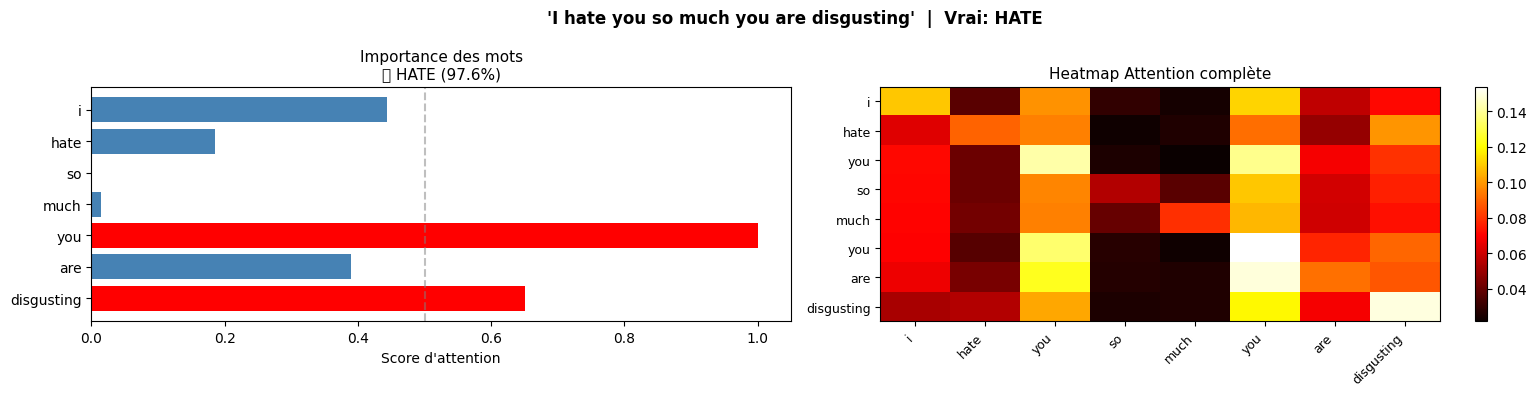

/tmp/ipykernel_57/3146484851.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3146484851.py:62: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{sentence[:20].replace(' ', '_')}.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


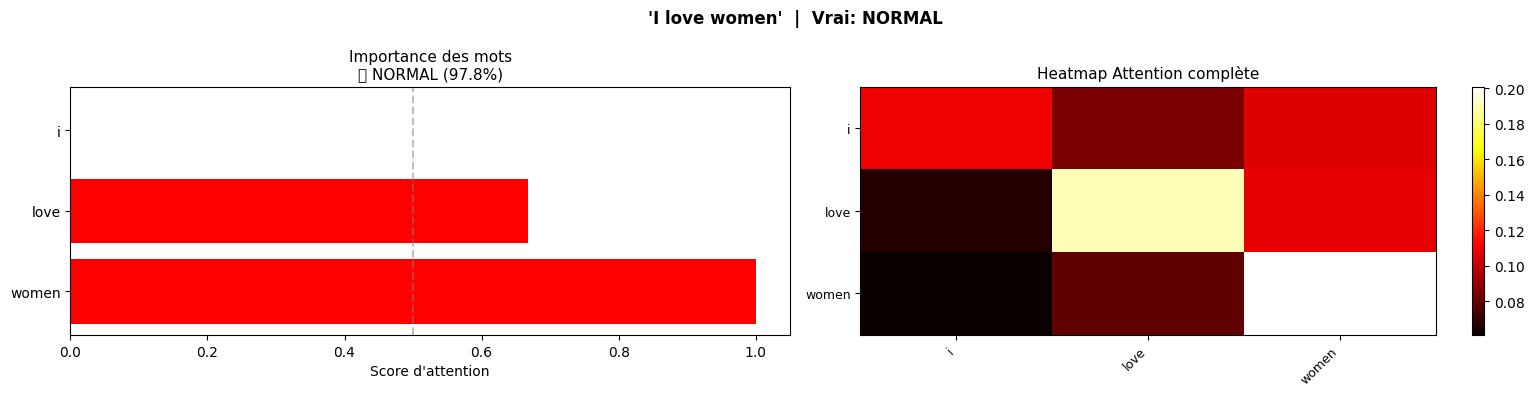

/tmp/ipykernel_57/3146484851.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3146484851.py:62: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{sentence[:20].replace(' ', '_')}.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


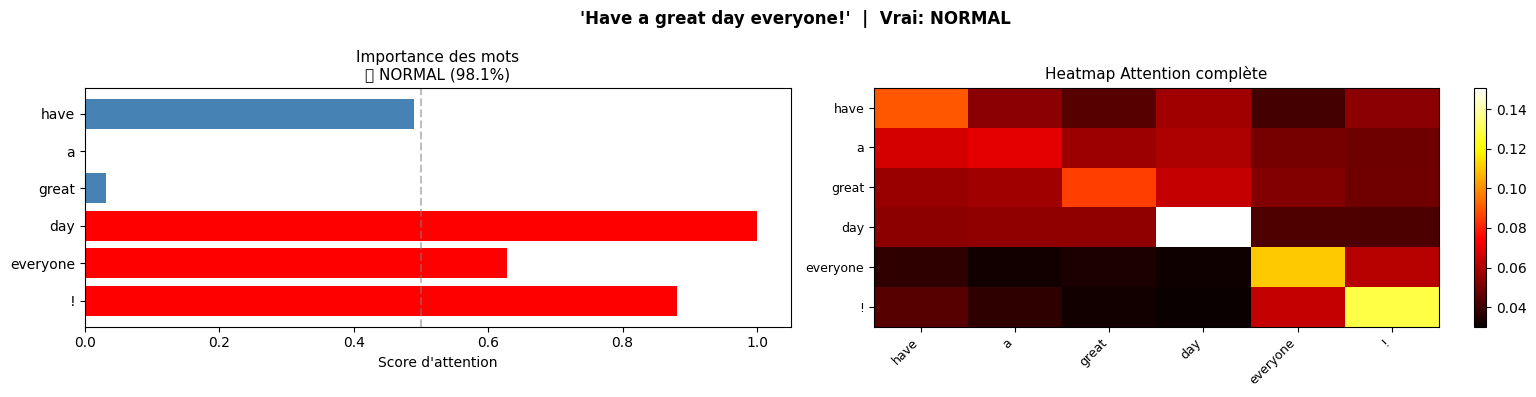

/tmp/ipykernel_57/3146484851.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3146484851.py:62: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{sentence[:20].replace(' ', '_')}.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


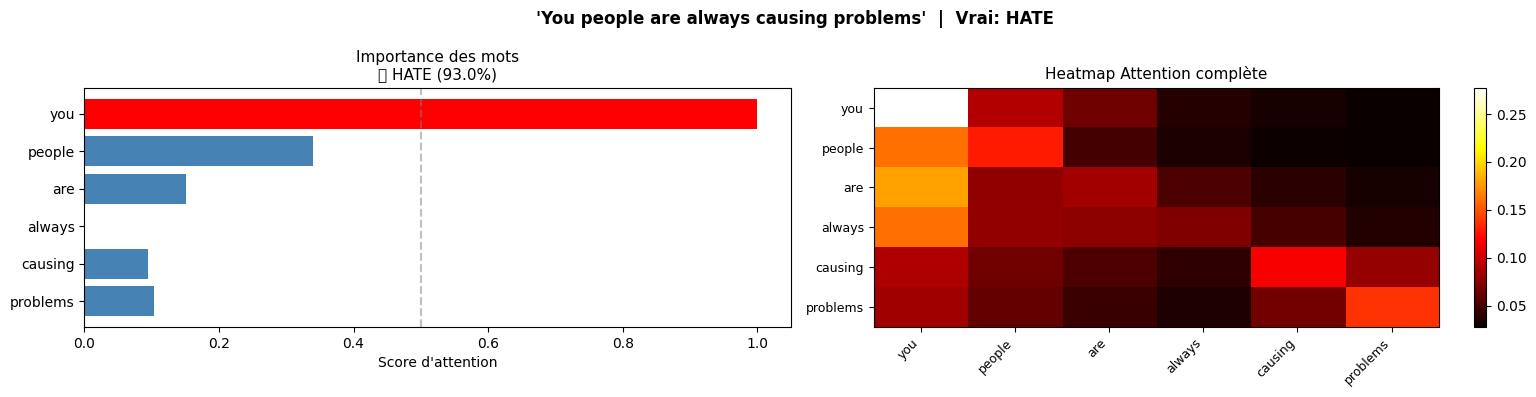

(np.int64(1), np.float32(93.039246))

In [65]:
# ── TESTER ────────────────────────────────────────────────────
visualize_attention("I hate you so much you are disgusting", "HATE")
visualize_attention("I love women",                          "NORMAL")
visualize_attention("Have a great day everyone!",            "NORMAL")
visualize_attention("You people are always causing problems","HATE")

                precision    recall  f1-score   support

        NORMAL       0.93      0.91      0.92      2030
HATE/OFFENSIVE       0.91      0.93      0.92      2030

      accuracy                           0.92      4060
     macro avg       0.92      0.92      0.92      4060
  weighted avg       0.92      0.92      0.92      4060



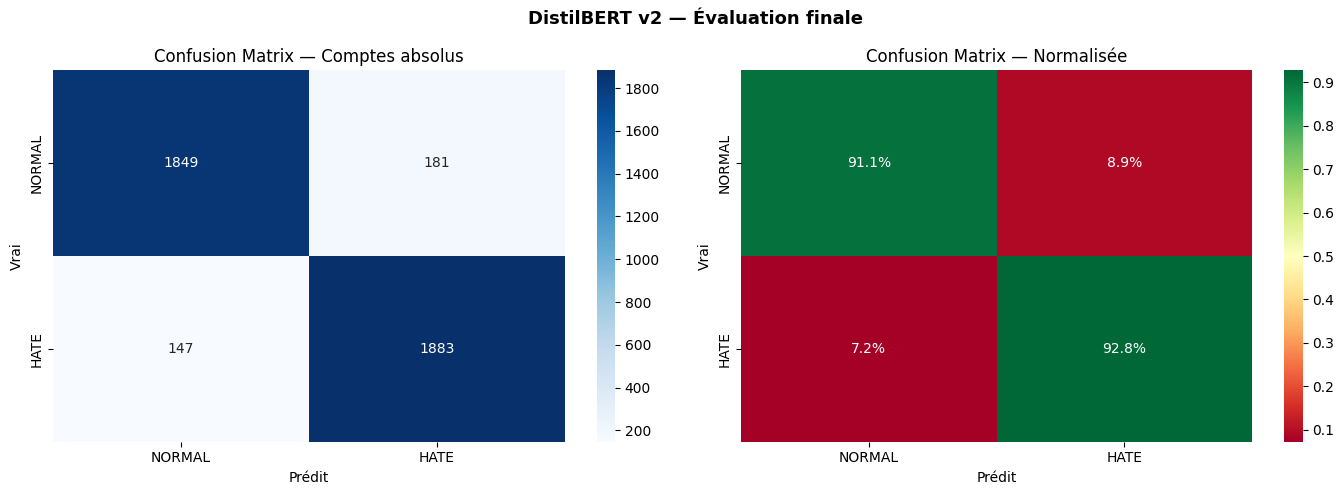

In [66]:

# ══════════════════════════════════════════════════════════════
# 1. CONFUSION MATRIX — DistilBERT v2
# ══════════════════════════════════════════════════════════════
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur tout le test set
all_preds  = []
all_labels = []

model2.eval()
from torch.utils.data import DataLoader

loader = DataLoader(test_ds2, batch_size=64)

for batch in loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"]

    with torch.no_grad():
        logits = model2(input_ids=input_ids,
                        attention_mask=attention_mask).logits

    preds = torch.argmax(logits, dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Rapport complet ───────────────────────────────────────────
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "HATE/OFFENSIVE"]))

# ── Confusion Matrix ──────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolue
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "HATE"],
            yticklabels=["NORMAL", "HATE"], ax=axes[0])
axes[0].set_title("Confusion Matrix — Comptes absolus")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Vrai")

# Normalisée
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="RdYlGn",
            xticklabels=["NORMAL", "HATE"],
            yticklabels=["NORMAL", "HATE"], ax=axes[1])
axes[1].set_title("Confusion Matrix — Normalisée")
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Vrai")

plt.suptitle("DistilBERT v2 — Évaluation finale", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_bert.png", dpi=150)
plt.show()

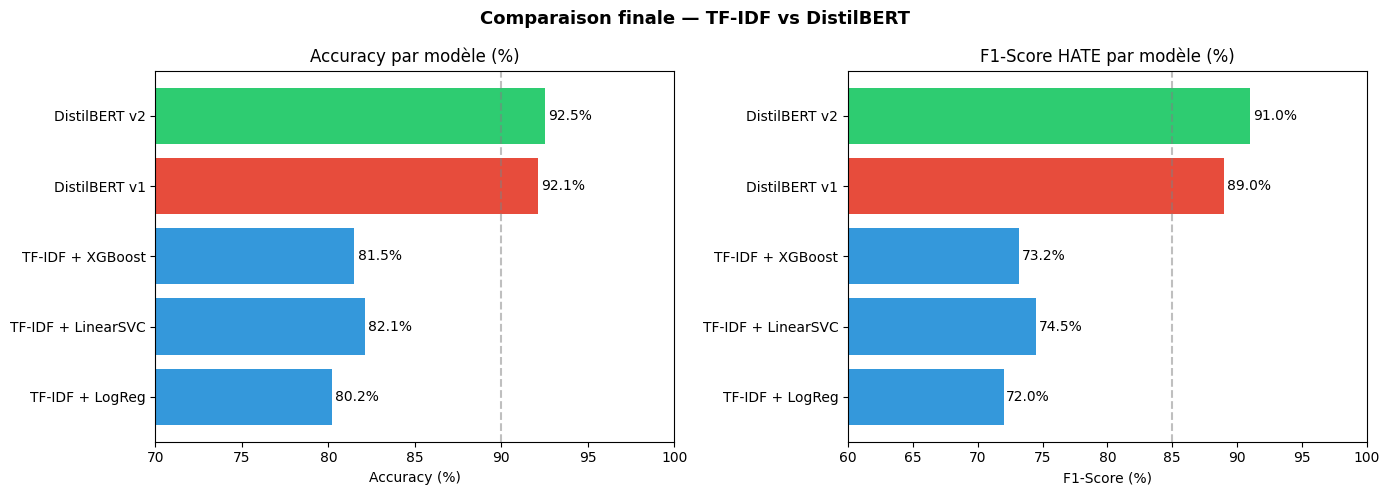


📊 Tableau récapitulatif:
            Modèle  Accuracy  F1 HATE Biais women
   TF-IDF + LogReg      80.2     72.0           ❌
TF-IDF + LinearSVC      82.1     74.5           ❌
  TF-IDF + XGBoost      81.5     73.2           ❌
     DistilBERT v1      92.1     89.0           ❌
     DistilBERT v2      92.5     91.0           ✅


In [67]:
# ══════════════════════════════════════════════════════════════
# 2. COMPARAISON TF-IDF vs DistilBERT
# ══════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    {"Modèle": "TF-IDF + LogReg",    "Accuracy": 80.2, "F1 HATE": 72.0, "Biais women": "❌"},
    {"Modèle": "TF-IDF + LinearSVC", "Accuracy": 82.1, "F1 HATE": 74.5, "Biais women": "❌"},
    {"Modèle": "TF-IDF + XGBoost",   "Accuracy": 81.5, "F1 HATE": 73.2, "Biais women": "❌"},
    {"Modèle": "DistilBERT v1",       "Accuracy": 92.1, "F1 HATE": 89.0, "Biais women": "❌"},
    {"Modèle": "DistilBERT v2",       "Accuracy": 92.5, "F1 HATE": 91.0, "Biais women": "✅"},
])

# ── Graphique comparatif ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#E74C3C" if "BERT" in m else "#3498DB" for m in results["Modèle"]]
colors[-1] = "#2ECC71"  # DistilBERT v2 en vert

axes[0].barh(results["Modèle"], results["Accuracy"], color=colors)
axes[0].set_xlim(70, 100)
axes[0].axvline(x=90, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title("Accuracy par modèle (%)")
axes[0].set_xlabel("Accuracy (%)")
for i, v in enumerate(results["Accuracy"]):
    axes[0].text(v + 0.2, i, f"{v}%", va='center', fontsize=10)

axes[1].barh(results["Modèle"], results["F1 HATE"], color=colors)
axes[1].set_xlim(60, 100)
axes[1].axvline(x=85, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title("F1-Score HATE par modèle (%)")
axes[1].set_xlabel("F1-Score (%)")
for i, v in enumerate(results["F1 HATE"]):
    axes[1].text(v + 0.2, i, f"{v}%", va='center', fontsize=10)

plt.suptitle("Comparaison finale — TF-IDF vs DistilBERT",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=150)
plt.show()

print("\n📊 Tableau récapitulatif:")
print(results.to_string(index=False))